<font size=6><b>Lec07.딥러닝 RNN - 시계열

# <font color=red><b>시계열 데이터
* https://otexts.com/fppkr/
* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 데이터(Non-Stationary)</b></font>
    - 시간에 따라 평균, 분산이 변화
    - 예측이 어렵고 통계 분석이 제한되므로 분석 전에 정상화 처리 필수
* <font color=red><b>비정상성 --> 정상성</b></font>
    - 평균 : 차분(Difference)
    - 분산 : 이동평균(MA:Moving Average),스케일링(MinMax), 로그변환(양수인경우)

# <font color=red><b>시계열 데이터의 특징

* <font color=red><b>추세(trend)</b></font>
    - 증가 감소 패턴
    - 물가상승
* <font color=red><b>계절성(seasonality)</b></font>
    - 짧은(주, 요일, 월) 빈도로 보이는 패턴(대체로 일정)
    - 블랙프라이데이 매출, 여름철우산판매량
* <font color=red><b>주기성(cycle)</b></font>
    - 장기적(고정 빈도가 없다)으로 증가/감소 패턴
    - 경기 순환(business cycle)
* <font color=red><b>백색잡음(white noise == epsilon)</b></font>
    - 균일한 크기의 무작위적 잡음

# <b>시계열 분석 데이터셋 topN

| 난이도   | Dataset                   | 설명                  | 특징                                | 데이터 크기        | Kaggle URL                                                                                                                                               |
| ----- | ------------------------- | ------------------- | --------------------------------- | ------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| *     | Shampoo Sales             | 월별 샴푸 판매량 (초소형 시계열) | RNN기초학습 | 36 rows       | [https://www.kaggle.com/datasets/jbrownlee/shampoo-sales](https://www.kaggle.com/datasets/jbrownlee/shampoo-sales)                                       |
| *     | <b>Airline Passengers</b>        | 월별 국제 항공 승객 수       | 주기,계절성(Trend,seasonality)학습       | 144 rows      | [https://www.kaggle.com/datasets/rakannimer/air-passengers](https://www.kaggle.com/datasets/rakannimer/air-passengers)                                   |
| **    | <b>--Daily Minimum Temperature</b> | 멜버른 일별 최소 기온        | 계절성(seasonality) 학습               | 3,650 rows    | [https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me](https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me) |
| **    | Sunspots                  | 태양 흑점 수             | 주기(periodicity) 데이터           | ~2,820 rows   | [https://www.kaggle.com/datasets/rohanrao/sunspots](https://www.kaggle.com/datasets/rohanrao/sunspots)                                                   |
| ***   | Electricity Consumption   | 전력 사용량 시계열          | 대규모 다변량 시계열                       | 200,000+ rows | [https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)             |
| ***   | Traffic Volume            | 교통량 데이터             |  다변량(날씨,시간,교통량)        | ~48,000 rows  | [https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume](https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume)           |
| ****  | <b>Bitcoin Price</b>             | 암호화폐 가격             | 고변동 금융 시계열                        | ~5,000+ rows  | [https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data)               |
| ****  | Stock Market              | 주가 시계열              | 다종목 금융 데이터                        | ~20,000+ rows | [https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset)                     |
| ***** | M5 Forecasting            | 대형 시계열 예측           | 세계 최대 리테일 시계열 대회                  | 30M+ rows     | [https://www.kaggle.com/competitions/m5-forecasting-accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy)                               |
| ***** | <b>Store Sales Forecasting</b>   | 매출 예측               | 다변량 매출                         | ~125k rows    | [https://www.kaggle.com/competitions/store-sales-time-series-forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)       |


# <b>Air Passengers

*  https://www.kaggle.com/datasets/rakannimer/air-passengers
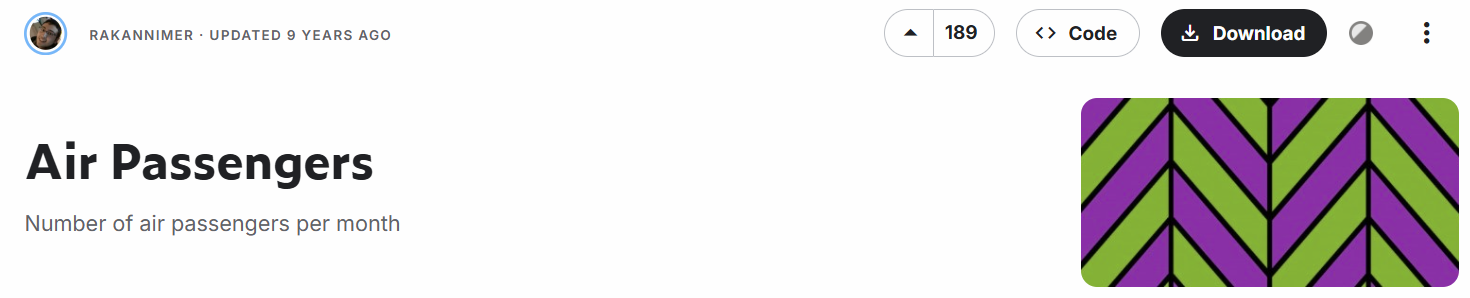

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
df = pd.read_csv("./dataset/AirPassengers.csv")
df.head(2)

,Month,#Passengers
0,1949-01,112
1,1949-02,118


In [3]:
df = pd.read_csv("./dataset/AirPassengers.csv", parse_dates=["Month"])
df.columns = ["rdate", "cnt"]
#df["rdate"] = df["rdate"].dt.strftime("%Y-%m")
#df["rdate"] = pd.to_datetime(df["rdate"], format="%Y-%m")
#pd.to_datetime(df["rdate"])
df.head(2)

,rdate,cnt
0,1949-01-01,112
1,1949-02-01,118


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   rdate   144 non-null    datetime64[ns]
 1   cnt     144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


# <b>EDA

In [5]:
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01-01,112
1949-02-01,118


In [6]:
df.index.min(), df.index.max()

(Timestamp('1949-01-01 00:00:00'), Timestamp('1960-12-01 00:00:00'))

<Figure size 640x480 with 0 Axes>

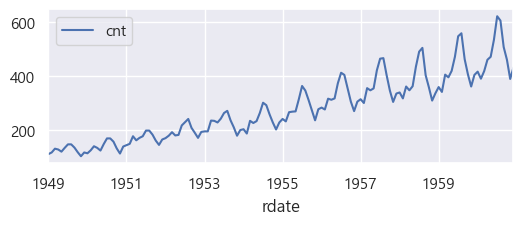

In [7]:
plt.figure()
df.plot(figsize=(6,2))
plt.show()

# <b>전처리 & 가공

* 정상성 데이터(Stationary)
    * 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    * 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 --> 정상성
    - 평균 : 차분(Difference)
    - 분산 : 이동평균(MA:Moving Average), 로그변환(양수인경우), 스케일링(MinMax)

**** 차분 - 윈도우 - 인풋사이즈 맞추기 시계열에서는 이 플로우 세가지 반드시 기억

## 차분(Difference)

In [8]:
df['diff1'] = df['cnt'].diff(1)
df['diff1'] = df['diff1'].bfill()
df.head()

,cnt,diff1
rdate,,
1949-01-01,112,6.0
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0


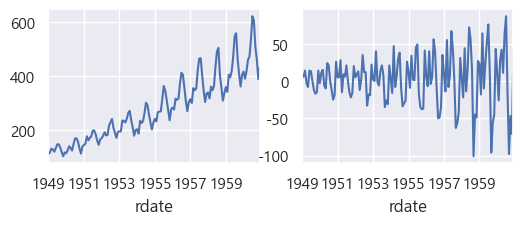

In [9]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(6,2))

plt.show()

## 이동평균(MA)
* 5(w), 20(m), 60(q), 120(2q:상반기/하반기), 200(y)

In [10]:
df['ma5']  = df['cnt'].rolling(5).mean()
df['ma20'] = df['cnt'].rolling(20).mean()
df.head(5)

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,NaN,NaN
1949-02-01,118,6.0,NaN,NaN
1949-03-01,132,14.0,NaN,NaN
1949-04-01,129,-3.0,NaN,NaN
1949-05-01,121,-8.0,122.4,NaN


### 결측채우기 : 앞/뒤 값으로 채우기
<pre><font color=red><b>df['컬럼'] = df['컬럼'].ffill() : 앞값으로 채우기
df['컬럼'] = df['컬럼'].bfill() : 뒤값으로 채우기

inplace=True XXXXXXXXXXXXXXXXXXXXXXXXXX 

In [11]:
df['ma5']  = df['ma5'].bfill()
df['ma20'] = df['ma20'].bfill()
df.head(6)

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,122.4,132.55
1949-02-01,118,6.0,122.4,132.55
1949-03-01,132,14.0,122.4,132.55
1949-04-01,129,-3.0,122.4,132.55
1949-05-01,121,-8.0,122.4,132.55
1949-06-01,135,14.0,127.0,132.55


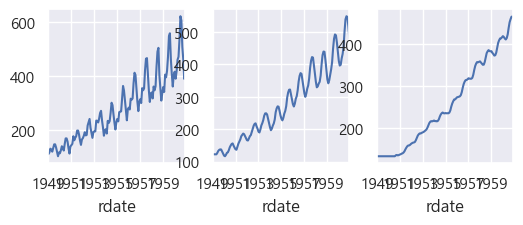

In [12]:
plt.figure()

plt.subplot(1,3,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,3,2)
df['ma5'].plot(figsize=(6,2))

plt.subplot(1,3,3)
df['ma20'].plot(figsize=(6,2))

plt.show()

## 로그변환(양수인경우)

In [13]:
df['log'] = np.log1p(df['cnt'])
df.head()

,cnt,diff1,ma5,ma20,log
rdate,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388
1949-02-01,118,6.0,122.4,132.55,4.779123
1949-03-01,132,14.0,122.4,132.55,4.890349
1949-04-01,129,-3.0,122.4,132.55,4.867534
1949-05-01,121,-8.0,122.4,132.55,4.804021


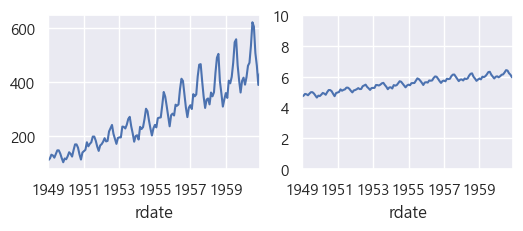

In [14]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['log'].plot(figsize=(6,2))
plt.ylim(0,10)

plt.show()

## 스케일링(MinMax)

In [15]:
df['cnt'].values.reshape(-1,1)[:3]

array([[112],
       [118],
       [132]])

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
res = scaler.fit_transform(df['cnt'].values.reshape(-1,1))  #------2D
res[:3]

array([[0.01544402],
       [0.02702703],
       [0.05405405]])

In [17]:
df['scale'] = res.reshape(-1)
df.head(2)

,cnt,diff1,ma5,ma20,log,scale
rdate,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027


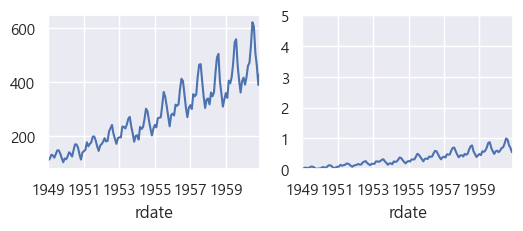

In [18]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['scale'].plot(figsize=(6,2))
plt.ylim(0,5)

plt.show()

## 정상성 데이터
* 평균(diff) , 분산(log)

In [19]:
df['stat'] = np.log1p(df['cnt'])
df['stat'] = df['stat'].diff(1)
df['stat'] = df['stat'].bfill()
df.head(2)

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736


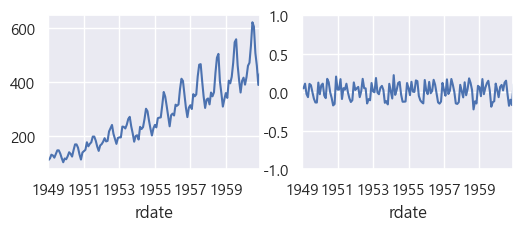

In [20]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(6,2))

plt.subplot(1,2,2)
df['stat'].plot(figsize=(6,2))
plt.ylim(-1,1)

plt.show()

# ===================================================================================================

# <b><font color=red>[1]가설 , 유의수준

<table><tr><Td><img src="https://mblogthumb-phinf.pstatic.net/MjAxOTA2MTdfNDYg/MDAxNTYwNzUwMTM1NzA0.49JWh_Q3vuC7apeZ0PcraCISbDUndRBPd99ltygM-KMg.59DOaEPcq41fY2X7-T5bf-8R7Dq1hu97Ba47qVn_Veog.PNG.igenius21c/%EC%9C%A0%EC%9D%98%ED%99%95%EB%A5%A0_%EC%9C%A0%EC%9D%98%EC%88%98%EC%A4%80_3.png?type=w800" width=600></Td>
<Td>H0 : 귀무가설(일반적사실)<br>
H1 : 대립가설(연구자가 입증하려는 사실)<br><br>
유의수준(기각될수준: 0.05) > 유의확률(p-value) <br>: 기각영역 --> 귀무가설이 틀리다 (연구자 말이 맞다)<br><br>      
유의수준(기각될수준: 0.05) < 유의확률(p-value) <br>: 채택영역 --> 귀무가설이 맞다 (연구자 말이 틀리다)<br>    
</Td></tr>
</table>

# <b><font color=red>[2]확률 분포

| 이산형 확률 변수 (Discrete random variable)<br>0,1,2 | 예                      | 연속형 확률 변수 (Continuous random variable) <br>23.49 52.17| 예             |
| ------------------------------------ | ---------------------- | -------------------------------------- | ------------- |
| 베르누이 분포                              | 동전 1회 던져 앞면(1) / 뒷면(0) | 균일 분포 (Uniform)                        | 0~1 사이 난수     |
| 이항 분포                                | 동전 10번 던져 앞면 개수        | **정규 분포 (Normal)** <br><br><br>**표준 정규 분포 (Z)**                        | 사람 키, 시험 점수<br><b>평균m 편차n 종모양 좌우대칭 분포도<br><b>평균0 편차1 종모양 좌우대칭 분포도<br>$  Z = \frac{X - \mu}{\sigma} $   |
| 기하 분포                                | 첫 성공이 나올 때까지 시행 횟수     | 지수 분포 (Exponential)                    | 고객 도착 간격 시간   |
| 다항 분포                                | 주사위 여러 번 던져 각 눈 개수     | <b>t-분포                                   | 표본평균 검정<br>$ t = \frac{\bar{x} - \mu}{s/\sqrt{n}} $       |
| 포아송 분포                               | 1시간 동안 콜센터 전화 수        | <b>카이제곱 분포 (χ²)                           | 분산 검정, 적합도 검정<br>$ \chi^2 = \sum \frac{(O - E)^2}{E} $ |
|                                      |                        | <b>F-분포       | 2개집단 분산 비교<br>$ F = \frac{s_1^2}{s_2^2} $  |
|                                      |                        | <b>ANOVA                                   | 3개집단 이상 평균비교<br>$ F = \frac{MS_{between}}{MS_{within}} $  |


<pre>
평균 : 
      중심극한의 정리 : 동전 10회 던저셔 앞면이 나올 확률(t) --> 무한(30<=)히 던저셔 앞면이 나올 확률(Z)
      t(1~2)    : n<30
      Z(1)      : n>=30
      ANOVA(3)

분산 : F-분포, 카이제곱

### Z
* https://ko.wikipedia.org/wiki/%ED%91%9C%EC%A4%80%EC%A0%95%EA%B7%9C%EB%B6%84%ED%8F%AC%ED%91%9C
* $  Z = \frac{X - \mu}{\sigma} $
<pre>시험성적
평균 : 70
표준편차 : 10
학생점수(x) : 85

In [21]:
z = (85 - 70) / 10
z   #면적(확률) : 0.93319	

1.5

### t
* https://ko.wikipedia.org/wiki/T%EB%B6%84%ED%8F%AC%ED%91%9C
* $ t = \frac{\bar{x} - \mu}{s/\sqrt{n}} $
* 모집단의 표준편차$ {\sigma} $를 모른다.
* 꼬리가 두껍다 == Z분포와 거의 흡사

<pre>시험성적
학생수 : 16
A집단평균 : 70
B집단평균 : 85
샘플표준편차 : 10

In [22]:
t = (85-70) / (10/4)
t  # 0.718

6.0

### 카이제곱
* https://en.wikipedia.org/wiki/Chi-squared_distribution
* $ \chi^2 = \sum \frac{(O - E)^2}{E} $
* <b>분산 검정
* <b>적합도 검정 : 특정 확률분포가 이론상의 확률분포와 얼마나 잘 맞는지 검정

<pre>     실제(%)     확률(%)
동전앞      40         50
동전뒤      60         50

In [23]:
앞 = ((40-50)**2)  / 50
뒤 = ((60-50)**2)  / 50
카이제곱 = 앞 + 뒤
카이제곱   # 0.71

4.0

### F
* 분산 비율
* $ F = \frac{s_1^2}{s_2^2} $

<pre>
A분산 : 25
B분산 : 10

In [24]:
F = 25 / 10
F

2.5

### ANOVA == F
* 3개집단 이상 평균비교
* $ F = \frac{MS_{between}}{MS_{within}} $
* $SS_{between} = \sum n_i(\bar{x_i} - \bar{x})^2$
* $SS_{within} = \sum \sum (x_{ij} - \bar{x_i})^2$
* 귀무가설 : 3집단의 평균의 차이는 없다

<pre>
A평균 = [65,70,75]
B평균 = [70,75,80]
C평균 = [78,82,86]    

In [25]:
A = [65, 70, 75]
B = [70, 75, 80]
C = [78, 82, 86]

groups = [A, B, C]

mean_A = (65 + 70 + 75) / 3
mean_B = (70 + 75 + 80) / 3
mean_C = (78 + 82 + 86) / 3

mean = (65 + 70 + 75 + 70 + 75 + 80 + 78 + 82 + 86) / 9

# (전체평균(m) - 그룹평균(x))**2
ss_between = len(A) * (mean_A - mean)**2 \
           + len(B) * (mean_B - mean)**2 \
           + len(C) * (mean_C - mean)**2
df_between = 3 - 1


# (그룹평균(m) - 그룹내개별값(x))**2
ss_within = sum((x - mean_A)**2 for x in A) \
          + sum((x - mean_B)**2 for x in B) \
          + sum((x - mean_C)**2 for x in C)
df_within = 9 - 3


ms_between = ss_between / df_between
ms_within  = ss_within / df_within

F = ms_between / ms_within

print("A 평균 =", mean_A)
print("B 평균 =", mean_B)
print("C 평균 =", mean_C)
print("전체평균 =", mean)

print("SS_between =", ss_between)
print("df_between =", df_between)

print("SS_within =", ss_within)
print("df_within =", df_within)


print("MS_between =", ms_between)
print("MS_within =", ms_within)

print("F =", F)

A 평균 = 70.0
B 평균 = 75.0
C 평균 = 82.0
전체평균 = 75.66666666666667
SS_between = 218.0
df_between = 2
SS_within = 132.0
df_within = 6
MS_between = 109.0
MS_within = 22.0
F = 4.954545454545454


# <b><font color=red>[3]통계 검정
* 귀무가설 --> 유의수준(0.05) --> 확률분포계산 --> 통계검정 --> 기각/채택

## 데이터 분포도 시각화

시각적 확인 (Visual Inspection)
 - 시계열 도표(Time Series Plot)
 - ACF/PCAF 그래프(정상 시계열은 시차가 커짐에 따라 ACF가 빠르게 0으로 수렴)
 - 분포도 (Q-Q Polt , pairplot , Histogram, Scatter)


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
sample_df = sns.load_dataset("mpg")

# 결측치 제거
sample_df = sample_df.dropna()
sample_df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


<Figure size 600x400 with 0 Axes>

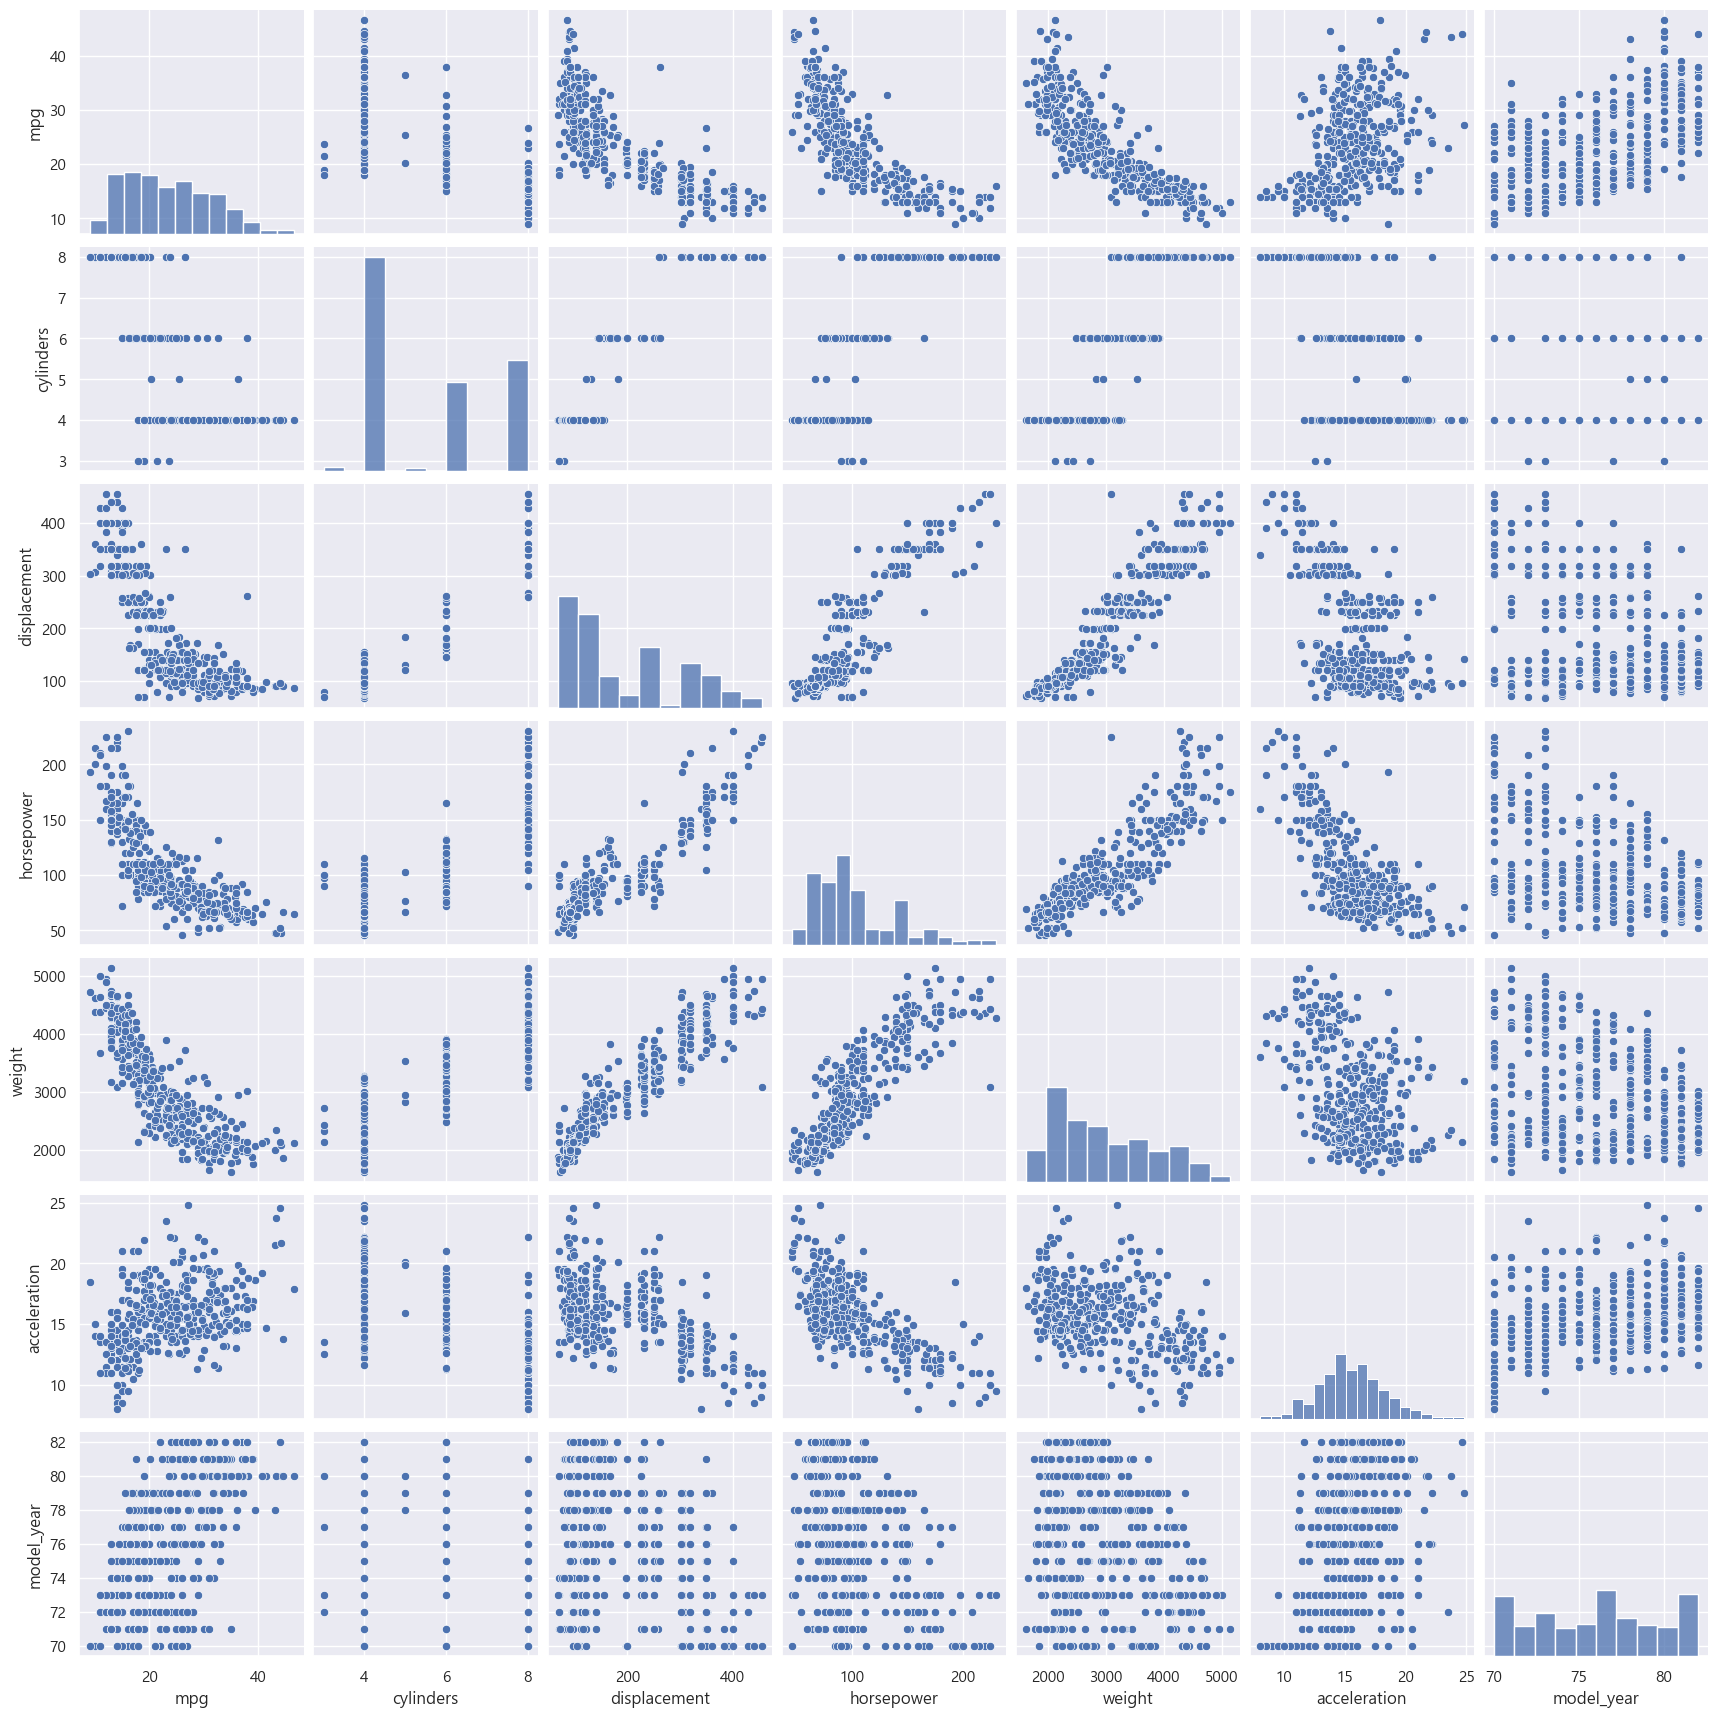

In [27]:
plt.figure(figsize=(6,4))
sns.pairplot(sample_df, diag_kind="hist")
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

def plt_show_3_graph(data):
    # 그래프 크기 설정
    fig, axes = plt.subplots(1, 2, figsize=(8,3))

    # 히스토그램
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title('Histogram(정규성)')

    # QQ 플롯
    # sm.qqplot(data, line='45', ax=axes[1])
    stats.probplot(data, plot=axes[1])
    axes[1].set_title('Q-Q Plot(정상성)')

    plt.tight_layout()
    plt.show()

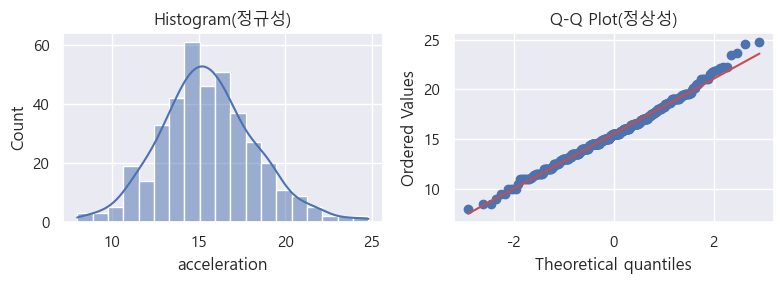

In [29]:
plt_show_3_graph (sample_df['acceleration']) 

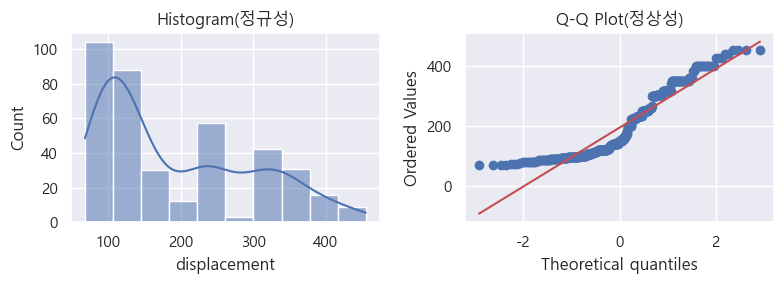

In [30]:
plt_show_3_graph (sample_df['displacement']) 

## 정상성 검정

 - <b>ADF 검정 (Augmented Dickey-Fuller)</b>
	- (H_0) : 데이터는 비정상성
	- p-value < 0.05 : 정상성으로 판단
 - KPSS 검정 (Kwiatkowski-Phillips-Schmidt-Shin)
	-  (H_0) : 데이터는 정상성
	- p-value > 0.05 : 정상성으로 판단
 - PP 검정 (Phillips-Perron)
	-  (H_0) : 데이터는 비정상성
	- p-value < 0.05 : 정상성으로 판단

In [31]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_test(x):
    x = pd.Series(x).dropna()

    adf_result = adfuller(x)
    print("[ADF]")
    #print("statistic :", adf_result[0])
    if adf_result[1] > 0.05 : 
        print("비정상성 p-value   :", adf_result[1])
    else :
        print("정상성 p-value   :", adf_result[1])
    #print("crit value:", adf_result[4])

    print()

    kpss_result = kpss(x, regression="c", nlags="auto")
    print("[KPSS]")
    #print("statistic :", kpss_result[0])
    print("p-value   :", kpss_result[1])
    if kpss_result[1] > 0.05 : 
        print("정상성 p-value   :", kpss_result[1])
    else :
        print("비정상성 p-value   :", kpss_result[1])
    #print("crit value:", kpss_result[3])

stationarity_test(df["cnt"])

[ADF]
비정상성 p-value   : 0.991880243437641

[KPSS]
p-value   : 0.01
비정상성 p-value   : 0.01


C:\Users\user\AppData\Local\Temp\ipykernel_25916\4003064211.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


In [32]:
stationarity_test(df["stat"]) 

[ADF]
비정상성 p-value   : 0.07907516260311181

[KPSS]
p-value   : 0.1
정상성 p-value   : 0.1


C:\Users\user\AppData\Local\Temp\ipykernel_25916\4003064211.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


## 정규성 검정

 - 샤피로-윌크 (Shapiro-Wilk) 
	- 일반적으로 n<50 소규모 데이터
	-  (H_0) : 데이터는 정규분포
	- p-value > 0.05 : 정규분포로 판단
 - 콜모고로프-스미르노프 (K-S) 
	- 일반적으로 n>=50 대규모 데이터
	-  (H_0) : 데이터는 정규분포
	- p-value > 0.05 : 정규분포로 판단


In [33]:
from scipy.stats import shapiro, kstest
import pandas as pd

def normality_test(x):
    x = pd.Series(x).dropna()

    shapiro_result = shapiro(x)
    print("[Shapiro-Wilk]")
    #print("statistic :", shapiro_result[0])
    if shapiro_result[1] > 0.05 : 
        print("정규분포 p-value   :", shapiro_result[1])
    else :
        print("XXX정규분포 p-value   :", shapiro_result[1])

    print()

    ks_result = kstest(x, "norm", args=(x.mean(), x.std()))
    print("[Kolmogorov-Smirnov]")
    #print("statistic :", ks_result[0])
    print("p-value   :", ks_result[1])
    if ks_result[1] > 0.05 : 
        print("정규분포 p-value   :", ks_result[1])
    else :
        print("XXX정규분포 p-value   :", ks_result[1])

In [34]:
normality_test(df["cnt"])

[Shapiro-Wilk]
XXX정규분포 p-value   : 6.832415574230731e-05

[Kolmogorov-Smirnov]
p-value   : 0.09747351318890995
정규분포 p-value   : 0.09747351318890995


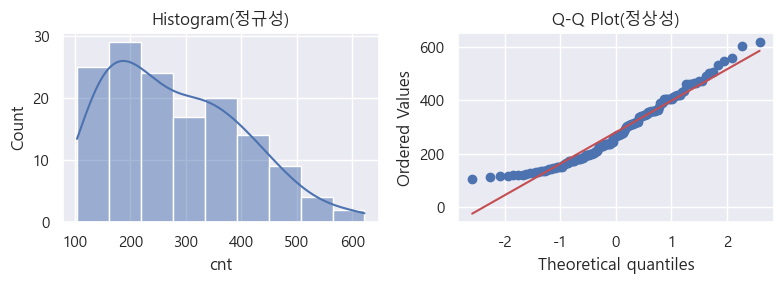

In [35]:
plt_show_3_graph(df["cnt"])

In [36]:
stationarity_test(df["stat"]) 

[ADF]
비정상성 p-value   : 0.07907516260311181

[KPSS]
p-value   : 0.1
정상성 p-value   : 0.1


C:\Users\user\AppData\Local\Temp\ipykernel_25916\4003064211.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


In [37]:
normality_test(df["stat"])

[Shapiro-Wilk]
XXX정규분포 p-value   : 0.0019869405651398793

[Kolmogorov-Smirnov]
p-value   : 0.351433319073157
정규분포 p-value   : 0.351433319073157


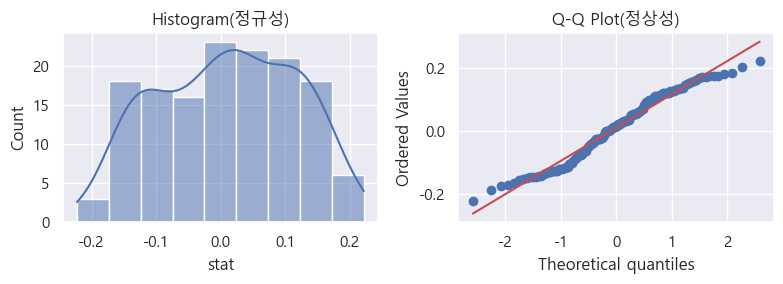

In [38]:
plt_show_3_graph(df["stat"])

## <b>양측검정 vs. 단측검정

<img src="http://infoso.kr/wp/wp-content/uploads/2020/10/%EC%A0%95%EA%B7%9C%EB%B6%84%ED%8F%AC2-1020x574.png" width="700">

<img src="https://static.wikidocs.net/images/page/198387/%EB%8B%A8%EC%B8%A1%EA%B2%80%EC%A0%95_%EC%96%91%EC%B8%A1%EA%B2%80%EC%A0%95.png" width=700>

* 단측검정  
    - 귀무가설 : 평균 >= 170
    - (170) ________
* 양측검정 
    - 귀무가설 : 평균 == 170
    -  _______ (170) ________

# ===================================================================================================

# <font color=red><b>ARIMA

In [39]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

| 구분                                          | 수식                                                            | 의미                   | 특징               |
| ------------------------------------------- | -------------------------------------------------------------- | -------------------- | ---------------- |
| **ACF** (Autocorrelation Function)          | $ \rho_k = \dfrac{Cov(X_t , X_{t-k})}{Var(X_t)} $               | 시계열과 k시차 값 사이 상관계수   | 직접 + 간접 영향 모두 포함 |
| **PACF** (Partial Autocorrelation Function) | $\phi_{kk} = Corr(X_t , X_{t-k} \mid X_{t-1},...,X_{t-k+1})$  | 중간 lag 영향을 제거한 순수 상관 | 직접 영향만 측정        |


| 항목        | ACF       | PACF      |
| --------- | --------- | --------- |
| 측정 관계     | 전체 상관     | 직접적 상관     |
| 중간 lag 영향 | 포함        | 제거        |
| <font color=red><b>MA 모델     | <font color=red><b>q(차수) 이후 절단   | 천천히 감소    |
| <font color=red><b>AR 모델     | 천천히 감소    | <font color=red><b>p(차수) 이후 절단   |
| ARMA 모델   | 둘 다 점진 감소 | 둘 다 점진 감소 |

* <font color=red><b> MA(q)  AR(p)
* <font color=red><b> ARIMA(p , d , q)
* <font color=red><b> p, q = (편)자기상관을 위한 차수
* <font color=red><b> d = 정상성을 위한 차수 

In [40]:
df = df.asfreq("MS")
df.head(2)

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736


## <b><font color=red>차분 : 정상성(d=1)

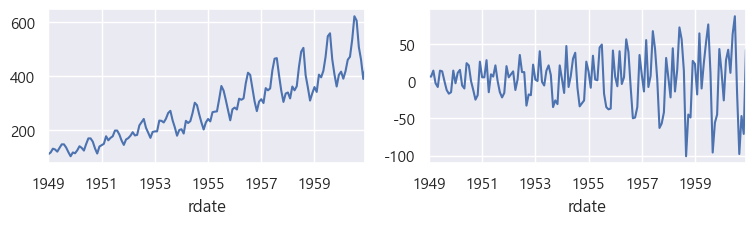

In [41]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(9,2))

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(9,2))

plt.show()

* <b>강한 추세(trend)와 계절성(seasonality)을 보인다.

## <font color=red><b>ACF(q)/PACF(p)
* https://www.statsmodels.org/stable/index.html
* https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html#statsmodels.graphics.tsaplots.plot_acf

``` python
statsmodels.graphics.tsaplots.plot_acf(x, ax=None, lags=None, *, alpha=0.05, use_vlines=True, adjusted=False, fft=False, missing='none', title='Autocorrelation', zero=True, auto_ylims=False, bartlett_confint=True, vlines_kwargs=None, **kwargs)

statsmodels.graphics.tsaplots.plot_pacf(x, ax=None, lags=None, alpha=0.05, method='ywm', use_vlines=True, title='Partial Autocorrelation', zero=True, vlines_kwargs=None, **kwargs)

class statsmodels.tsa.arima.model.ARIMA(endog, exog=None, order=(0, 0, 0), seasonal_order=(0, 0, 0, 0), trend=None, enforce_stationarity=True, enforce_invertibility=True, concentrate_scale=False, trend_offset=1, dates=None, freq=None, missing='none', validate_specification=True)

* <b><font color=red>자기상관 확인 (lags=40)

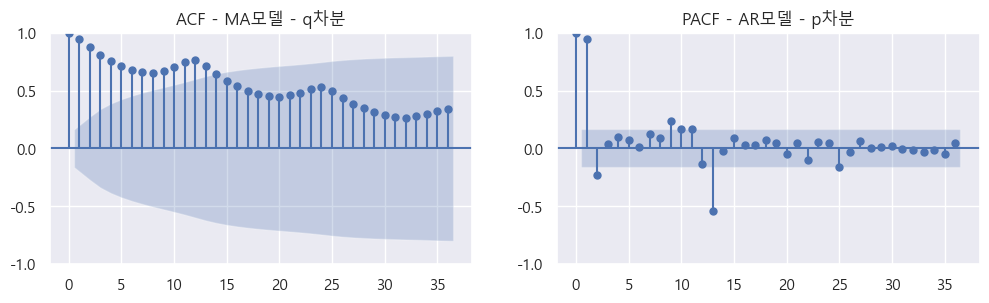

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,3))

plot_acf(df['cnt'] , lags=36, ax=axes[0] , title='ACF - MA모델 - q차분')
plot_pacf(df['cnt'], lags=36, ax=axes[1] , title='PACF - AR모델 - p차분')

plt.show()

In [43]:
df.index.max()

Timestamp('1960-12-01 00:00:00')

In [44]:
model = ARIMA(df['cnt'][:-12] ,  order=(1, 1, 0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)   #12개월 예측  ---  24(시) 30(일) 12(월) 4(분기)
forecast

1960-01-01    417.522421
1960-02-01    421.169189
1960-03-01    422.231198
1960-04-01    422.540475
1960-05-01    422.630542
1960-06-01    422.656772
1960-07-01    422.664410
1960-08-01    422.666635
1960-09-01    422.667283
1960-10-01    422.667471
1960-11-01    422.667526
1960-12-01    422.667542
Freq: MS, Name: predicted_mean, dtype: float64

In [45]:
df['cnt'][-12:]

rdate
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: cnt, dtype: int64

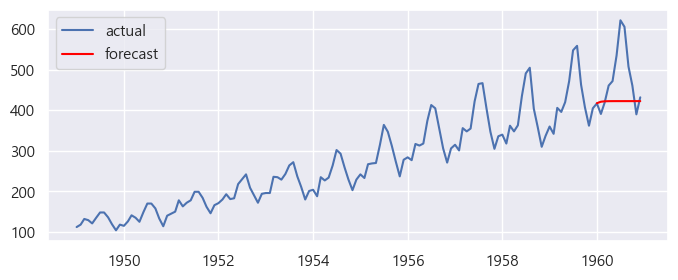

In [46]:
plt.figure(figsize=(8,3))

plt.plot(df['cnt'], label="actual")
plt.plot(forecast, label="forecast", color="red")

plt.legend()
plt.show()

# <b>SARIMAX

In [47]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['cnt'][:-12], order=(1,1,0), seasonal_order=(1,1,0,12))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

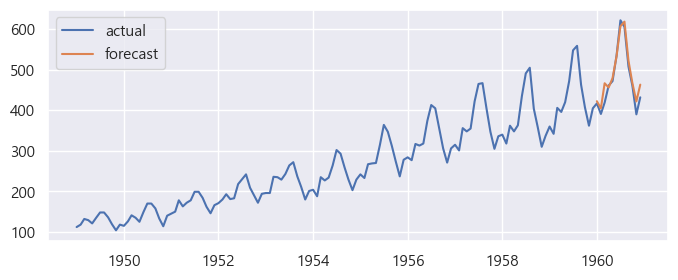

In [48]:
plt.figure(figsize=(8,3))
plt.plot(df['cnt'], label="actual")
plt.plot(forecast, label="forecast")
plt.legend()
plt.show()

* log 현상이 해도 해도 너무한다

# <font color=red><b>딥러닝 : LSTM

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fb6kVlm%2Fbtq4Cs5VOPX%2FAAAAAAAAAAAAAAAAAAAAAMYQoJiEudo_8wyGznteHfaLNELmur5pNYm9-sjkzJMG%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D3p5ZsREruPh0ibYMuTxdC0vR1nw%253D" width=600>

In [49]:
df = pd.read_csv("./dataset/AirPassengers.csv", parse_dates=["Month"])
df.columns = ["rdate", "cnt"]
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01-01,112
1949-02-01,118


## 윈도우 슬라이딩(원리이해)

<img src="https://images.velog.io/images/findingflow/post/088196e2-54ae-4d82-a2a3-7c3110545fca/image.png" width=600>

* <font color=red><b>1차 : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [50]:
arr = np.arange(11)
arr

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [51]:
window_size = 6
X = []
y = []
for i in range(len(arr) - window_size):
    X.append( arr[i : i+window_size] )
    y.append( arr[i+window_size]     )
print( np.array(X) )
print( np.array(y) )

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


* <font color=red><b>2차 arr : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [52]:
arr = np.arange(11).reshape(-1,1)
arr[:3], arr.shape

(array([[0],
        [1],
        [2]]),
 (11, 1))

In [53]:
window_size = 6
X = []
y = []
for i in range(len(arr) - window_size):
    X.append( arr[i : i+window_size, 0] )
    y.append( arr[i+window_size, 0]     )
print( np.array(X) )
print( np.array(y) )

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


* <font color=red><b>2차 dataframe : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [54]:
arr = np.arange(11).reshape(-1,1)
arr_df = pd.DataFrame(arr)
arr_df.head(3)

,0
0,0
1,1
2,2


In [55]:
window_size = 6
X = []
y = []
for i in range(len(arr_df) - window_size):
    X.append( arr_df.iloc[i : i+window_size, 0] )
    y.append( arr_df.iloc[i+window_size, 0]     )
print( np.array(X) )
print( np.array(y) )

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


## <b> 전처리 & 가공

* 정상성 변환

In [56]:
df['cnt'] = np.log1p(df['cnt'])
df['cnt'] = df['cnt'].diff(1)
df['cnt'] = df['cnt'].bfill()
df.head(2)

,cnt
rdate,
1949-01-01,0.051736
1949-02-01,0.051736


* 윈도우 슬라이딩

In [57]:
window_size = 12
X = []
y = []
for i in range(len(df) - window_size):
    X.append( df.iloc[i : i+window_size, 0] )
    y.append( df.iloc[i+window_size, 0]     )
X = np.array(X)
y = np.array(y)
print( X.shape , X[:3])
print( y.shape , y[:5] )

(132, 12) [[ 0.05173567  0.05173567  0.11122564 -0.02281468 -0.06351341  0.10863384
   0.09129142  0.         -0.08396538 -0.13248918 -0.13353139  0.12516314]
 [ 0.05173567  0.11122564 -0.02281468 -0.06351341  0.10863384  0.09129142
   0.         -0.08396538 -0.13248918 -0.13353139  0.12516314 -0.0255333 ]
 [ 0.11122564 -0.02281468 -0.06351341  0.10863384  0.09129142  0.
  -0.08396538 -0.13248918 -0.13353139  0.12516314 -0.0255333   0.0905969 ]]
(132,) [-0.0255333   0.0905969   0.11163997 -0.04317217 -0.07637298]


## <b>LSTM 모델
* https://keras.io/api/layers/recurrent_layers/lstm/

``` python
keras.layers.LSTM(
    units,
    activation="tanh",
    recurrent_activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal",
    bias_initializer="zeros",
    unit_forget_bias=True,
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    use_cudnn="auto",
    **kwargs
)

### <font color=red size=7><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

In [58]:
print( X.shape )
print( X.reshape(132, 12, 1).shape )
print( X.reshape(X.shape[0], X.shape[1], 1) .shape )

X = X.reshape(X.shape[0], X.shape[1], 1)

(132, 12)
(132, 12, 1)
(132, 12, 1)


## <b> 학습 & 평가

In [59]:
model = Sequential([
    LSTM(units=50,  activation='relu' , input_shape=(window_size,1) ) ,   #12, 1개피쳐(cnt)
    Dense(units=1 )      #----- output layer   
 ]) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
X

array([[[ 0.05173567],
        [ 0.05173567],
        [ 0.11122564],
        ...,
        [-0.13248918],
        [-0.13353139],
        [ 0.12516314]],

       [[ 0.05173567],
        [ 0.11122564],
        [-0.02281468],
        ...,
        [-0.13353139],
        [ 0.12516314],
        [-0.0255333 ]],

       [[ 0.11122564],
        [-0.02281468],
        [-0.06351341],
        ...,
        [ 0.12516314],
        [-0.0255333 ],
        [ 0.0905969 ]],

       ...,

       [[-0.12861738],
        [-0.11686434],
        [ 0.11195033],
        ...,
        [ 0.15041236],
        [-0.02601773],
        [-0.17608077]],

       [[-0.11686434],
        [ 0.11195033],
        [ 0.02912827],
        ...,
        [-0.02601773],
        [-0.17608077],
        [-0.09688313]],

       [[ 0.11195033],
        [ 0.02912827],
        [-0.06421959],
        ...,
        [-0.17608077],
        [-0.09688313],
        [-0.16685733]]], shape=(132, 12, 1))

In [61]:
from sklearn.model_selection import train_test_split
X80,X20,y80,y20 = train_test_split(X, y , test_size=0.2, shuffle=False)
X80.shape

(105, 12, 1)

In [62]:

model.compile(loss="mse" , optimizer="adam",  metrics=["mse"]) 
fit_res = model.fit(X80, y80,  epochs=20, validation_data=(X20, y20) )
loss,mse = model.evaluate(X20, y20)
print(f"loss:{loss:.4f} " )

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0112 - mse: 0.0112 - val_loss: 0.0123 - val_mse: 0.0123
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0125 - val_mse: 0.0125
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0111 - mse: 0.0111 - val_loss: 0.0125 - val_mse: 0.0125
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0123 - val_mse: 0.0123
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0109 - mse: 0.0109 - val_loss: 0.0121 - val_mse: 0.0121
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0109 - mse: 0.0109 - val_loss: 0.0120 - val_mse: 0.0120
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - mse: 0.0108 - val_loss: 0.0120 - val_mse: 0.0120
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0107 - mse: 0.0107 - val_loss: 0.0119 - val_mse: 0.0119
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0107 - mse: 0.0107 - 

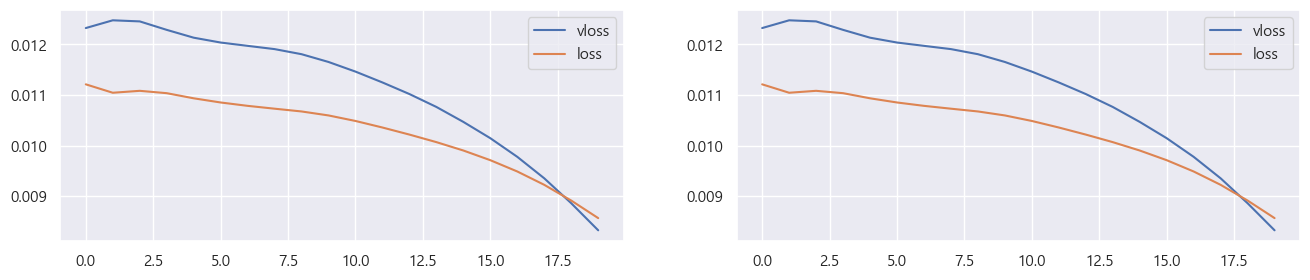

In [63]:
plt.figure(figsize=(16,3))
plt.subplot(1,2,1)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

In [64]:
X.shape

(132, 12, 1)